<a href="https://colab.research.google.com/github/CY-PI/_ML_PUCRIO/blob/main/MVP_ML_Analytics_20261_Cyntia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**Nome:** Cyntia P. Invernizzi  
**Matrícula:** 4052026001020  
**Data:** 05/06/2026  
**Dataset:** IBM HR Analytics Employee Attrition & Performance, Kaggle (https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset)  
**Tipo de problema:** Classificação

---

## Observações importantes

Este notebook é um **template** para o desenvolvimento do MVP da Sprint de Machine Learning & Analytics. Ele não deve ser preenchido de forma mecânica: adapte as seções ao problema escolhido e remova partes que não fizerem sentido.

O objetivo do MVP é demonstrar um fluxo completo e bem documentado de Machine Learning: definição do problema, entendimento dos dados, preparação, modelagem, avaliação e discussão crítica dos resultados.

> **Atenção:** profundidade e clareza valem mais do que quantidade de técnicas. É melhor apresentar uma solução simples, bem justificada e executável do que testar muitos modelos sem análise.

> **Atenção 2:** o dataset utilizado neste template é apenas um exemplo sintético para que o notebook execute sem erros. Substitua pela base escolhida, carregada por URL pública ou fonte diretamente acessível no Colab.

TESTE

## Checklist do MVP

Use este checklist antes da entrega.

| Item | Status |
|---|---|
| Problema definido com contexto, objetivo e tipo de tarefa | ☐ |
| Dataset descrito, com fonte, atributos e restrições | ☐ |
| Dataset carregado por URL pública ou fonte diretamente acessível | ☐ |
| Análise exploratória objetiva, conectada à modelagem | ☐ |
| Divisão adequada em treino/teste e, se aplicável, validação | ☐ |
| Prevenção de vazamento de dados | ☐ |
| Tratamentos de dados justificados | ☐ |
| Pipeline ou sequência reprodutível de pré-processamento | ☐ |
| Modelo baseline definido | ☐ |
| Pelo menos dois modelos/abordagens comparados, quando aplicável | ☐ |
| Ajuste de hiperparâmetros em pelo menos um modelo, quando aplicável | ☐ |
| Avaliação com métricas coerentes com o problema | ☐ |
| Discussão de overfitting/underfitting, limitações e melhorias | ☐ |
| Código limpo, organizado e executável do início ao fim | ☐ |
| Conclusão conectada ao objetivo inicial | ☐ |

> **Comentário:** nem todo item se aplica igualmente a todos os tipos de problema. Por exemplo, clusterização pode não ter target; séries temporais exigem divisão temporal; deep learning e fine-tuning são opcionais.


# 1. Definição do problema

## 1.1 Descrição do problema
Trabalhando com um dataset de Recursos Humanos, construirei um modelo de classificação para prever risco de "attrition" de um funcionário (risco do funcionário sair da empresa).
Atualmente, existe uma forte procura por analistas de People Analytics, que trabalham junto ao RH das empresas, para que entendam problemas relacionados à pessoas, incluindo este. Este modelo especificamente seria para o uso de analistas de recursos humanos que trabalham em parceria com a gerencia da empresa.
Este problema é relevante por alguns motivos:
1. Com uma lista de talentos extremamente importantes, uma empresa poderia simular risco destas pessoas sairem e trabalhar caso a caso com os indivíduos em risco, oferecendo pacotes de retenção de longo prazo, como exemplo.
2. Se houver chance de identificar as features com maior peso no modelo, Recursos Humanos poderia criar planos de ação visando melhorias, como programa de inclusão, oferecimento de 2 dias por ano para trabalho voluntário, etc.

## 1.2 Objetivo do MVP

O objetivo deste MVP é construir e avaliar modelos de classificação para prever o risco de attrition de funcionários, comparando uma abordagem baseline com modelos candidatos e discutindo suas limitações. Também busca identificar quais variáveis mais influenciam essa decisão, através da interpretabilidade dos modelos.


## 1.3 Tipo de problema

**Tipo escolhido:** Classificação

**Justificativa:** O output pretendido para prever attrition é "Sim" (1) ou "Não" (0), que são duas categorias discretas. Portanto, se trata de um modelo de classificação.


## 1.4 Premissas, hipóteses e critérios de sucesso

Liste as principais hipóteses e como você pretende verificar se o MVP foi bem-sucedido.

**Hipótese inicial:**
As 3 features abaixo são as que mais influenciam a demissão de um funcionário:
1. EnvironmentSatisfaction: quanto menor, maior o risco;
2. Work-life balance: quanto menor, maior o risco;
3. Tempo no mesmo cargo: indicaria falta de reconhecimento ou promoção (quanto maior, maior o risco).

**Critérios de sucesso:**
- Métrica principal: recall. Esta métrica faz mais sentido pois o target é desbalanceado e precisamos minimizar os falsos negativos (mesmo que seja a custa de aumentar os falso positivos). Essa premissa se baseio no fato de que perder talentos gera mais custo para empresa do que mantê-los [(clique aqui para acessar fonte)](https://midfalconi.com/artigo/retencao-de-talentos-medias-empresas).
Porém, também é importante analisar o balanço entre recall e precision, para que fique dentro de níveis aceitáveis. Também queremos ter certeza que o modelo separar as classes competentemente, portanto AUC-ROC também se faz importante.

- Resultado mínimo esperado:
    - Recall: por volta de 70%
    - F1-score: por volta de 80%
    - AUC-ROC: por volta de 80%

- Restrição prática: interpretabilidade do modelo pode representar uma limitação, dependendo do escolhido. (?) _ex.: tempo de treino, interpretabilidade, simplicidade, custo computacional._

XXXXXXXXXXXXXXXXXXXXXXXXXXX

> **Comentário:** não basta dizer que “o modelo ficou bom”. Defina antes o que significa “bom” para este problema.


# 2. Ambiente, bibliotecas e reprodutibilidade

Esta seção deve reunir as importações, configuração de seed e informações básicas do ambiente.

**O que incluir:**
- bibliotecas utilizadas;
- seed fixa para reprodutibilidade;
- observações sobre GPU/CPU, quando relevante;
- versões de bibliotecas, se houver dependências específicas.


## 2.1 Dependências adicionais

Biblioteca extra: XGBoost e PPScore

In [106]:
!pip install -q xgboost


## 2.2 Todas as Bibliotecas

In [107]:
# === Setup básico e reprodutibilidade ===

# Importing Libraries ====================
# import os
import sys
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import importlib

from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, TimeSeriesSplit, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, f1_score, roc_auc_score, classification_report, ConfusionMatrixDisplay
from sklearn.svm import SVC
# from sklearn.feature_selection import mutual_info_classif
# from sklearn.inspection import permutation_importance

from scipy.stats import randint, uniform, loguniform, pointbiserialr, chi2_contingency

from xgboost import XGBClassifier

# import shap

warnings.filterwarnings("ignore")

# Setting up Seed
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Versões das bibliotecas utilizadas:")
print("\t - python:", sys.version.split()[0])
for lib in ["pandas", "numpy", "matplotlib", "scikit-learn", "xgboost"]:
  print(f"\t - {lib}: {importlib.metadata.version(lib)}")

print("\nSeed:", SEED)


Versões das bibliotecas utilizadas:
	 - python: 3.12.13
	 - pandas: 2.2.2
	 - numpy: 2.0.2
	 - matplotlib: 3.10.0
	 - scikit-learn: 1.6.1
	 - xgboost: 3.2.0

Seed: 42


## 2.2 Funções auxiliares

Use funções para evitar repetição e deixar o notebook mais organizado.

> **Comentário:** não é obrigatório criar classes. Em notebooks de ML, funções bem nomeadas geralmente já melhoram bastante a legibilidade.


In [108]:
def evaluate_classification(y_true, y_pred, proba=None):
    """Calcula métricas básicas para classificação."""
    results = {
        "recall": recall_score(y_true, y_pred),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted"),
    }

    # ROC AUC é mais direto para classificação binária com probabilidades.
    try:
        if proba is not None and proba.shape[1] == 2:
            results["roc_auc"] = roc_auc_score(y_true, proba[:, 1])
        else:
            results["roc_auc"] = np.nan
    except Exception:
        results["roc_auc"] = np.nan

    return results


def show_results_table(results_dict):
    """Exibe resultados como DataFrame ordenável."""
    return pd.DataFrame(results_dict).T


# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

- Nome do dataset: IBM HR Analytics Employee Attrition & Performance;
- Link da fonte: https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset


Este dataset foi escolhido porque eu gostaria de resolver um problema parecido com o que uma pessoa que trabalha em People Analytics teria.

Ele estava disponível publicamente no Kaggle e os dados são sintéticos, o que evitaria questões éticas, de privacidade, confidencialidade ou licença.

Em relação a restrições/condições consideradas, achei que os tamanho do arquivo no Kaggle era pequeno suficiente para ser colocado no github (50KB) ao mesmo tempo em que 1470 linhas seriam suficientes para treinar o modelo.

## 3.2 Carga dos dados


In [109]:
# === Carga dos dados ===
url = "https://raw.githubusercontent.com/CY-PI/_ML_PUCRIO/refs/heads/main/WA_Fn-UseC_-HR-Employee-Attrition.csv"
df = pd.read_csv(url)

df.head()


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## 3.3 Visão geral do dataset

Antes de modelar, apresente uma visão geral da base.

**O que incluir:**
- quantidade de linhas e colunas;
- tipos dos atributos;
- valores ausentes;
- duplicatas;
- possíveis colunas de ID, data ou variáveis que não devem entrar no modelo;
- descrição do target, se houver.


###3.3.1 Formato do Dataset

In [110]:
print("Formato do dataset:", df.shape)
print("\nTipos de dados:")
display(df.dtypes.to_frame("tipo"))

Formato do dataset: (1470, 35)

Tipos de dados:


,tipo
Age,int64
Attrition,object
BusinessTravel,object
DailyRate,int64
Department,object
DistanceFromHome,int64
Education,int64
EducationField,object
EmployeeCount,int64
EmployeeNumber,int64


###3.3.2 Valores ausentes

In [111]:
print("\nValores ausentes por coluna:")
nulos = df.isna().sum().to_frame("ausentes")
count_nulos = nulos["ausentes"].sum()
if count_nulos == 0:
  print("Não há colunas com esta condição.")
else:
  display(nulos[nulos["ausentes"] > 0])


Valores ausentes por coluna:
Não há colunas com esta condição.


###3.3.3 Valores duplicados

In [112]:
print("\nDuplicatas:", df.duplicated().sum())



Duplicatas: 0


###3.3.4 Amostra do dataset

In [113]:
display(df.sample(5, random_state=SEED))

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1041,28,No,Travel_Rarely,866,Sales,5,3,Medical,1,1469,...,4,80,0,6,4,3,5,4,1,3
184,53,No,Travel_Rarely,1084,Research & Development,13,2,Medical,1,250,...,3,80,2,5,3,3,4,2,1,3
1222,24,Yes,Travel_Rarely,240,Human Resources,22,1,Human Resources,1,1714,...,3,80,1,1,2,3,1,0,0,0
67,45,No,Travel_Rarely,1339,Research & Development,7,3,Life Sciences,1,86,...,3,80,1,25,2,3,1,0,0,0
220,36,No,Travel_Rarely,1396,Research & Development,5,2,Life Sciences,1,304,...,4,80,0,16,3,4,13,11,3,7


###3.3.5 Colunas que devem ser excluídas do modelo

In [114]:
ID_COLUMNS = ["EmployeeNumber"]

# Excluir colunas que tenham valor constante + DailyRate e HourlyRate (vide explicação no item 3.4)
DROP_COLUMNS = list(df.columns[df.nunique() == 1].tolist() + ["DailyRate", "HourlyRate"])

columns_to_exclude = set(ID_COLUMNS + DROP_COLUMNS)

print("Colunas que devem ser excluídas do modelo:")
for item in sorted(columns_to_exclude):
  print("\t -", item)

Colunas que devem ser excluídas do modelo:
	 - DailyRate
	 - EmployeeCount
	 - EmployeeNumber
	 - HourlyRate
	 - Over18
	 - StandardHours


###3.3.6 Descrição do target

O target do modelo é a coluna "Attrition", que mostra se um funcionário pediu demissão ou não. Os dados são desbalanceados (84% não e 16% sim).

## 3.4 Dicionário de dados

| Coluna | Tipo | Descrição | Será usada no modelo? | Observações |
|---|---|---|---|---|
| Age	| numérica | idade do funcionário | sim | transformar em categorias XXXXXXX |
| BusinessTravel	| categórica | frequencia de viagem do funcionário | sim | N/A |
| DailyRate	| numérica | valor do salário por hora | não | Excluindo porque já estou incluindo a MonthlyRate |
| Department | categórica | xxx | sim | xxx |
| DistanceFromHome | numérica | distância do trabalho até a residência (em milhas) | sim | N/A |
| Education	| ordinal | Nível de educação dos funcionários | sim | 1: Below College; 2: College; 3: Bachelor; 4: Master; 5: Doctor |
| EducationField	| categórica | xxx | sim | xxx |
| EmployeeCount	| numérica | xxx | não | cada funcionário aparece uma única vez, nã há necessidade de contar |
| EmployeeNumber | numérica | ID dos funcionários | não | N/A |
| EnvironmentSatisfaction	| ordinal | Satisfação com o ambiente físico/cultural de trabalho | sim | 1: Low; 2: Medium; 3: High; 4: Very High |
| Gender | categórica | Sexo dos funcionários | sim | N/A |
| HourlyRate	| numérica | valor do salário por hora | não | Excluindo porque já estou incluindo a MonthlyRate |
| JobInvolvement | ordinal | dedicação ao trabalho | sim | 1: Low; 2: Medium; 3: High; 4: Very High |
| JobLevel | ordinal | xxx | sim | N/A |
| JobRole	| categórica | xxx | sim | N/A |
| JobSatisfaction	| ordinal | Satisfação com o cargo | sim | 1: Low; 2: Medium; 3: High; 4: Very High |
| MaritalStatus	| categórica | xxx | sim | N/A |
| MonthlyIncome	| numérica | xxx | sim | N/A |
| MonthlyRate	| numérica | valor do salário por hora | sim | N/A |
| NumCompaniesWorked | numérica | número de empresas em que o funcionário já trabalhou | sim | N/A |
| Over18 | texto | indica se o funcionário é maior de 18 anos | não | todos os funcionários são maiores de 18 |
| OverTime | binária | indica se o funcionário faz horas extras | sim | N/A |
| PercentSalaryHike	| numérica | percentual de aumento de salário no último ciclo | sim | N/A |
| PerformanceRating	| ordinal | xxx | sim | 1: Low; 2: Good; 3: Excellent; 4: Outstanding |
| RelationshipSatisfaction | ordinal | satisfação no relacionamento interpessoal no trabalho | sim |	1: Low; 2: Medium; 3: High; 4: Very High |
| StandardHours	| numérica | número padrão de horas trabalhadas | não | é o mesmo para todos os funcionários |
| StockOptionLevel	| ordinal | xxx | sim | N/A |
| TotalWorkingYears	| numérica | Total de anos trabalhados | sim | N/A |
| TrainingTimesLastYear	| numérica | número de treinamentos no ano anterior | sim | N/A |
| WorkLifeBalance	| ordinal | Nível de balanço entre vida pessoal e trabalho | sim | 1: Bad, 2: Good, 3: Better, 4: Best |
|YearsAtCompany	| numérica | Tempo de empresa | sim | N/A |
| YearsInCurrentRole | numérica | Tempo no cargo atual | sim | N/A |
| YearsSinceLastPromotion	| numérica | Tempo desde a última promoção | sim | N/A |
| YearsWithCurrManager	| numérica | Tempo com o mesmo gerente | sim | N/A |
| Attrition	| binária | Target do modelo, conforme detalhado no item 3.3.6 | Sim | N/A |



# 4. Análise exploratória dos dados

A análise exploratória deve ser objetiva e conectada ao problema.

**O que incluir:**
- distribuição do target; ok
- distribuição de variáveis importantes;
- relação entre variáveis e target;
- identificação de desbalanceamento, outliers ou padrões relevantes;
- hipóteses que surgem a partir dos dados.

> **Comentário:** siga a lógica do MVP de pré-processamento: não basta mostrar gráfico; escreva abaixo dele o que o gráfico indica e como isso influencia a modelagem.


##4.1 Distribuição do target

In [115]:
TARGET = "Attrition"
PROBLEM_TYPE = "classificacao"

print("Distribuição do target:")

tabela_contagem = df[TARGET].value_counts(dropna=False).to_frame("Contagem")
tabela_contagem["Percentual (%)"] = (df[TARGET].value_counts(normalize=True, dropna=False) * 100).round(2)

print(tabela_contagem.to_markdown(tablefmt="grid"))



Distribuição do target:
+-------------+------------+------------------+
| Attrition   |   Contagem |   Percentual (%) |
+=============+============+==================+
| No          |       1233 |            83.88 |
+-------------+------------+------------------+
| Yes         |        237 |            16.12 |
+-------------+------------+------------------+


Observa-se o target é desbalanceado com 84% "Não" e 16% "Sim".

##4.2 Relação das variáveis com o target

###4.2.1 Relação das variáveis numéricas e ordinais com o target

Para calcular a relação entre variáveis numéricas e o target binário, podemos utilizar o pointbiserialr. Esta métrica calcula a média da variável numérica para cada classe do target. Uma diferença significativa entre as médias resultaria em uma correlação alta.

In [116]:
# Identificando importância das features numéricas e ordinais
y_binary = (df[TARGET] == "Yes").astype(int)

# definindo target e colunas a considerar
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols = [n for n in num_cols if n not in columns_to_exclude]

# Calculando correlação entre variáveis e target
correlations = {}
for col in num_cols:
    corr, pvalue = pointbiserialr(df[col], y_binary)
    correlations[col] = {"correlation": abs(corr), "pvalue": pvalue}

num_ranking = pd.DataFrame(correlations).T.sort_values("correlation", ascending=False)
print("Relação das variáveis numéricas com o target:")
print(num_ranking.to_string(float_format="{:.4f}".format))

Relação das variáveis numéricas com o target:
                          correlation  pvalue
TotalWorkingYears              0.1711  0.0000
JobLevel                       0.1691  0.0000
YearsInCurrentRole             0.1605  0.0000
MonthlyIncome                  0.1598  0.0000
Age                            0.1592  0.0000
YearsWithCurrManager           0.1562  0.0000
StockOptionLevel               0.1371  0.0000
YearsAtCompany                 0.1344  0.0000
JobInvolvement                 0.1300  0.0000
JobSatisfaction                0.1035  0.0001
EnvironmentSatisfaction        0.1034  0.0001
DistanceFromHome               0.0779  0.0028
WorkLifeBalance                0.0639  0.0142
TrainingTimesLastYear          0.0595  0.0226
RelationshipSatisfaction       0.0459  0.0787
NumCompaniesWorked             0.0435  0.0955
YearsSinceLastPromotion        0.0330  0.2058
Education                      0.0314  0.2293
MonthlyRate                    0.0152  0.5611
PercentSalaryHike              0.0

###4.2.2 Relação das variáveis categóricas com o target

Para calcular a correlaçao entre variáveis categóricas com o target binário, utilizaremos Cramér's V, baseado no chi quadrado (chi2_contingency). Esta métrica é adequada para medir a associação entre duas variáveis categóricas, retornando um valor entre 0 e 1.

In [117]:
# Identificando importância das features categóricas
cat_cols = df.select_dtypes(include="object").columns.tolist()
cat_cols = [col for col in cat_cols if col not in columns_to_exclude and col != TARGET]

cat_correlations = {}
n = len(df)

for col in cat_cols:
  contingency_matrix = pd.crosstab(df[col], df[TARGET])
  chi2 = chi2_contingency(contingency_matrix)[0]
  if min(contingency_matrix.shape) > 1:
    cat_correlations[col] = {"correlation": np.sqrt(chi2 / (n * (min(contingency_matrix.shape) - 1))), "pvalue": pvalue}
  else:
    cat_correlations[col] = {"correlation": 0, "pvalue": 1}

cat_ranking = pd.DataFrame(cat_correlations).T.sort_values("correlation", ascending=False)
print("Relação das variáveis categóricas com o target:")
print(cat_ranking.to_string(float_format="{:.4f}".format))


Relação das variáveis categóricas com o target:
                correlation  pvalue
OverTime             0.2441  0.0000
JobRole              0.2421  0.0000
MaritalStatus        0.1772  0.0000
BusinessTravel       0.1283  0.0000
EducationField       0.1044  0.0000
Department           0.0857  0.0000
Gender               0.0276  0.0000


###4.2.3 Observações

Embora esta seja uma análise simples, ao calcular a correlação de todas as variáveis acima, notamos que a mais alta foi 24.6%. Isso mostra que não há features com forte relação linear com o target e que talvez, no momento de avaliar modelos, seja uma boa idéia comparar modelos que lidam com relações lineares com outros que lidam com relações mais complexas.

##4.3 Distribuição de variáveis importantes

###4.3.1 Definindo as variáveis importantes

Aqui, definiu-se que as variáveis mais importantes são as que apresentam pvalue < 5% (significância estatística), mas que tenham relevância (correlação de pelo menos 10%). Por exemplo, embora "Gender" tenha pvalue de aproximadamente 0, a correlação é muito baixa, portanto não seria uma variável importante neste momento.

In [118]:
# Numéricas e Ordinais
important_num = (num_ranking[(num_ranking["correlation"] > 0.10) & (num_ranking["pvalue"] < 0.05)])
important_num = important_num.sort_index().index.tolist()

print("Variáveis numéricas e ordinais mais importantes:\n")
for var in important_num:
  print(var)

# Categóricas
important_cat = cat_ranking[(cat_ranking["correlation"] > 0.10) & (cat_ranking["pvalue"] < 0.05)]
important_cat = important_cat.sort_index().index.tolist()

print("\nVariáveis categóricas mais importantes:\n")
for var in important_cat:
  print(var)

Variáveis numéricas e ordinais mais importantes:

Age
EnvironmentSatisfaction
JobInvolvement
JobLevel
JobSatisfaction
MonthlyIncome
StockOptionLevel
TotalWorkingYears
YearsAtCompany
YearsInCurrentRole
YearsWithCurrManager

Variáveis categóricas mais importantes:

BusinessTravel
EducationField
JobRole
MaritalStatus
OverTime


### 4.3.2 Distribuição de variáveis numéricas (excluindo ordinais)

Distribuição de colunas numéricas


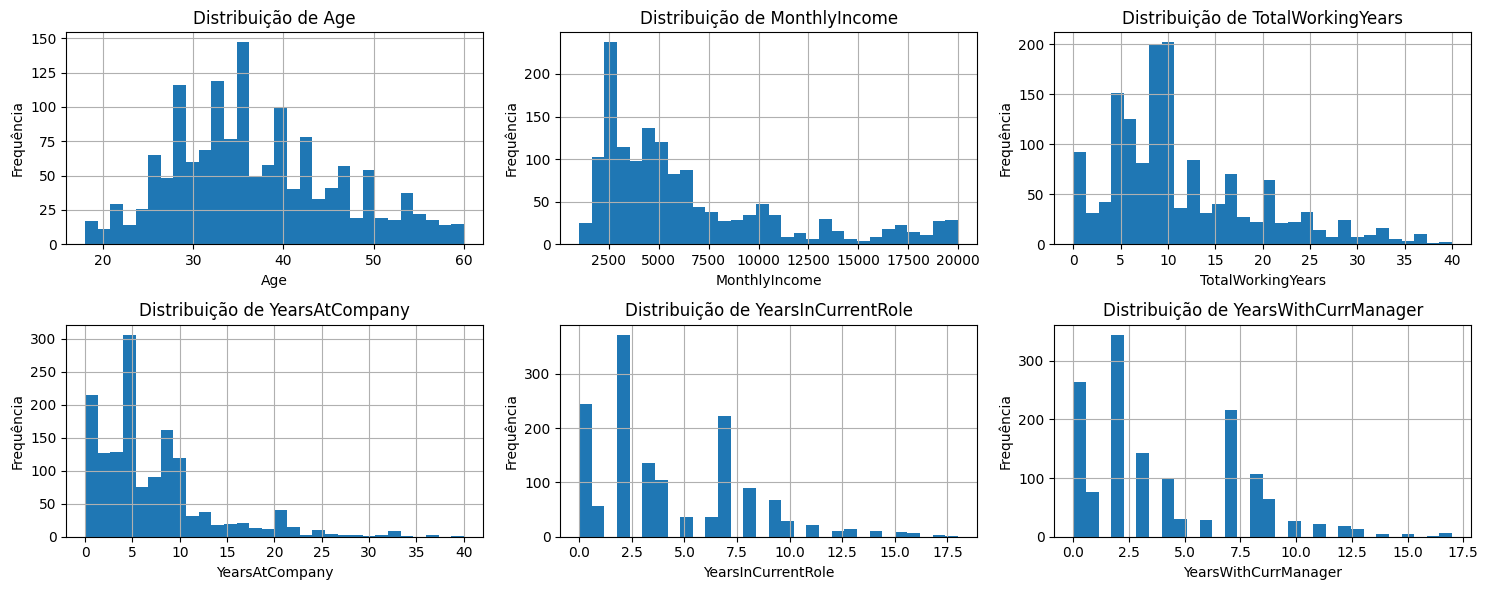

In [119]:
ordinals = ["EnvironmentSatisfaction", "JobInvolvement", "JobLevel", "JobSatisfaction", "StockOptionLevel"]
important_num_exc_ord = [col for col in important_num if col not in ordinals]

# Criando subplot para guardar os gráficos de distribuição:
numcols = 3
num_rows = math.ceil(len(important_num_exc_ord)/ numcols)
plt.figure(figsize=(15, numcols * num_rows))

print("Distribuição de colunas numéricas", end="\n")
for i, col in enumerate(important_num_exc_ord):
  # posição na plot
  if col in ordinals:
    continue
  else:
    plt.subplot(num_rows, numcols, i + 1)

    df[col].hist(bins=30)
    plt.title(f"Distribuição de {col}")
    plt.xlabel(col)
    plt.ylabel("Frequência")

plt.tight_layout()
plt.show()

Observa-se que, enquanto a distribuição de idade (age) segue uma curva próxima a normal, o gráfico das demais variáveis são right-skewed (longa cauda para a direita), o que indica a presença de outliers.
Nota-se também que a variável MonthlyIncome possui uma escala muito maior que as demais features, sendo necessária normalização na etapa de pré-processamento.

### 4.3.2 Distribuição de variáveis categóricas, ordinais e binárias.

Distribuição de colunas categóricas


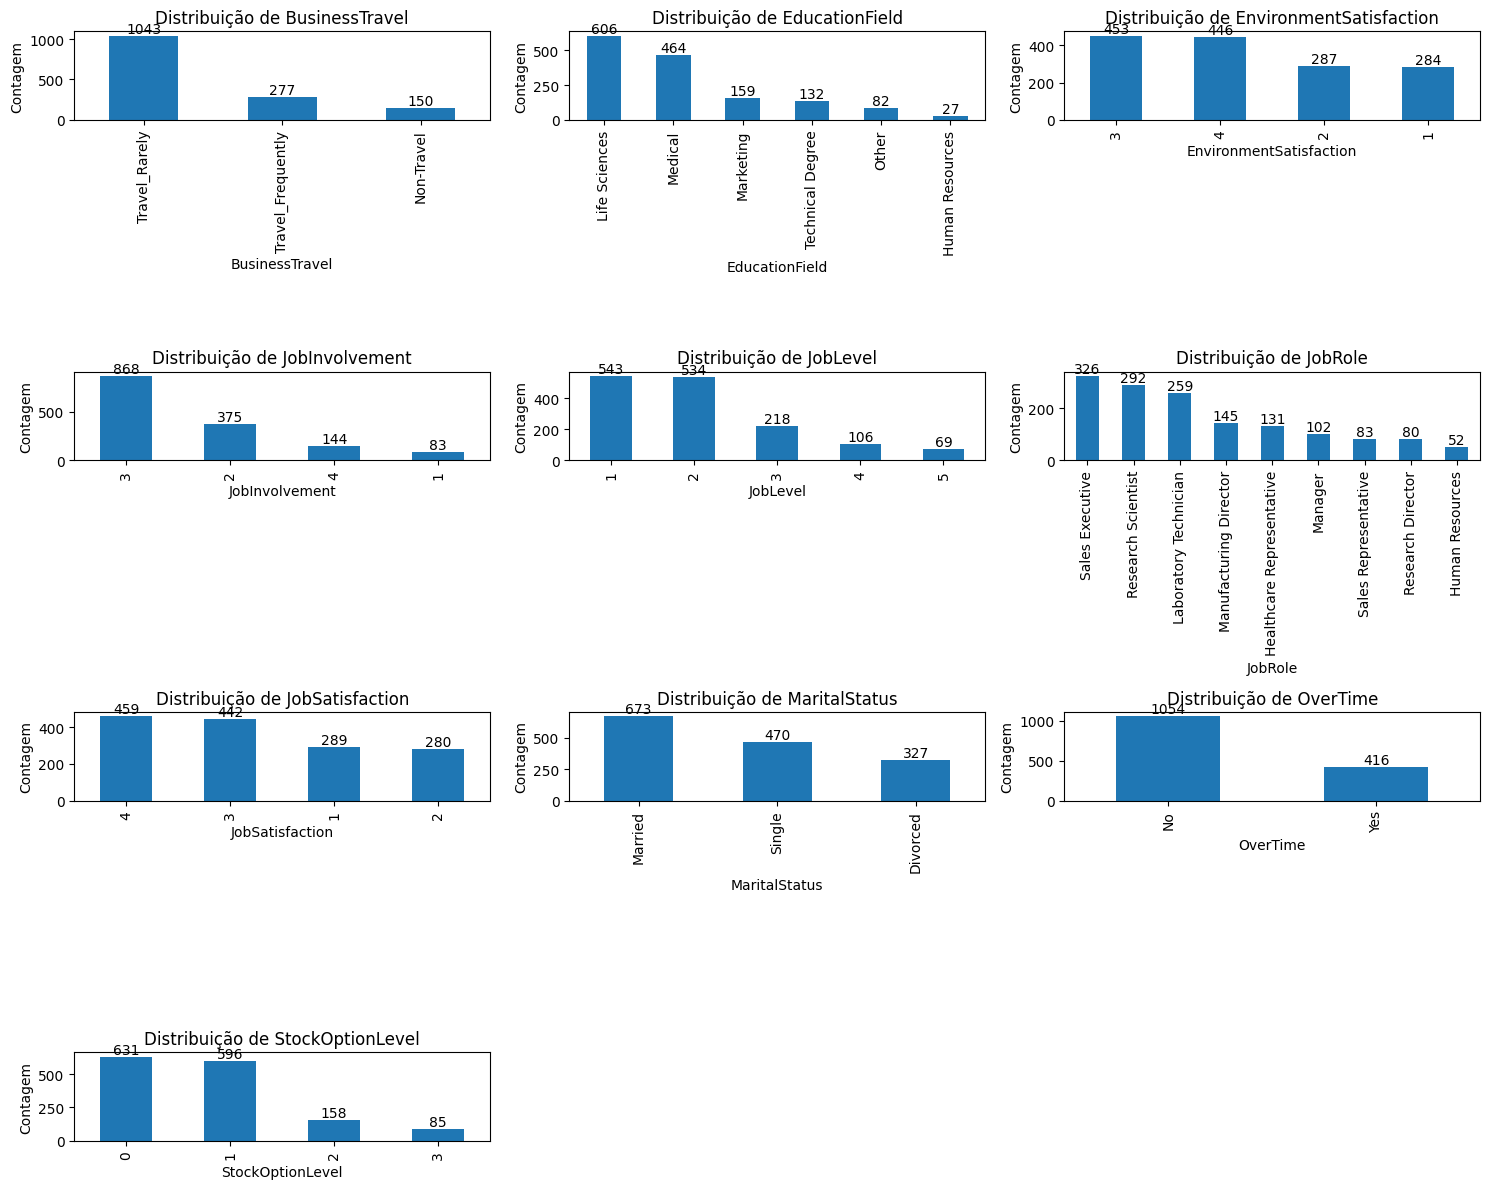

In [120]:
important_cat_ord = sorted(important_cat + ordinals)

# Criando subplot para guardar os gráficos de distribuição:
num_rows = math.ceil(len(important_cat_ord) / numcols)
plt.figure(figsize=(15, numcols * num_rows))

print("Distribuição de colunas categóricas", end="\n")
for i, col in enumerate(important_cat_ord):
  # posição na plot
  plt.subplot(num_rows, numcols, i + 1)

  plot = df[col].value_counts().plot(kind="bar")
  plot.bar_label(plot.containers[0])

  plt.title(f"Distribuição de {col}")
  plt.xlabel(col)
  plt.ylabel("Contagem")

plt.tight_layout()
plt.show()

Várias features acima tem categorias com poucos exemplos. Por exemplo, BusinessTravel tem um número alto para funcionários que viajam raramente, mas muito pequeno para os que não viajam, ou JobLevel onde o nível 5 tem somente 69 exemplos. Nas features onde isso acontece, podemos ter o poder de predição reduzido.
Para evitar aplicar OneHotEncoder na variável "OverTime", pode-se transformar as classes "Yes" / "No" em 1/0.

## 4.4 Síntese da análise exploratória

Ao analisar os dados, notamos:
1. A análise simples de correlação das variáveis com o target mostrou que deveremos utilizar modelos que lidam tanto com relações lineares (LogisticRegression) como com mais complexas (RandomForest, XGBoost, etc).
2. O target desbalanceado (16% "Sim") indica que precisaremos utilizar estratificação (stratify=y) para separar dados de treino e teste, tentando manter a mesma proporção (84% sim/16% não) para cada set de dados. Para avaliar os modelos, usaremos class_weight="balanced" ou scale_pos_weight=scale_xgboost para dar maior peso à classe minoritária.
3. O dataset extraído do kaggle não contém valores nulos ou duplicados, o que ajuda a simplificar o pré-processamento de dados.
4. O gráfico das variáveis numéricas é right-skewed. Neste caso, faria sentido utilizar a mediana para preencher dados nulos, se houvesse algum.
5. A feature "MonthlyIncome" tem uma escala muito maior do que a das outras variáveis numéricas, portanto usaremos scaler=StandardScaler() no pré-processamento, que ajuda a ajustar as variáveis numéricas para a mesma escala. Isso evitará que esta feature domine o modelo.
6. O poder de predição de algumas das features pode ser afetado pelo fato de algumas de suas classes possuirem poucos exemplos.


# 5. Preparação dos dados e divisão treino/teste

Nesta etapa, defina claramente quais colunas serão utilizadas, qual é o target e como os dados serão divididos.

**O que incluir:**
- separação entre features e target;
- remoção de colunas que não devem ser usadas;
- divisão treino/teste;
- validação, quando aplicável;
- justificativa para a divisão escolhida.

> **Comentário:** para problemas temporais, não embaralhe os dados. Use divisão baseada no tempo.

##5.1 Remoção de colunas que não devem ser usadas

In [121]:
if TARGET is not None:
    columns_to_exclude.add(TARGET)

df["OverTime"] = df["OverTime"].map({"No": 0, "Yes": 1}).astype(int)
# print(df["OverTime"])

features = [c for c in df.columns if c not in columns_to_exclude]

### 5.1.1 Configuração do modelo

In [122]:
print("Tipo de problema:", PROBLEM_TYPE)
print("Target:", TARGET)
print("Número de features:", len(features))
print("Features:", features)

Tipo de problema: classificacao
Target: Attrition
Número de features: 28
Features: ['Age', 'BusinessTravel', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


## 5.2 Divisão dos dados

In [123]:
# === Divisão dos dados ===

X = df[features].copy()
y = df[TARGET].copy()

y = LabelEncoder().fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, random_state=SEED, stratify=y
)

print("Treino:", X_train.shape, "| Teste:", X_test.shape)


Treino: (1176, 28) | Teste: (294, 28)


## 5.1 Justificativa da divisão

Explique por que a divisão escolhida é adequada.

**O que comentar:**
- Por que usar holdout, validação cruzada ou divisão temporal?
- A proporção treino/teste faz sentido para o tamanho do dataset?
- Foi necessário estratificar as classes?
- Como a divisão evita vazamento de dados?

**Resposta:**  
A proporção treino/teste foi mantida em 80% treino / 20% teste porque o dataset utilizado é pequeno e devemos ter dados suficientes para treinar o modelo.

Não houve manipulação de dados antes da divisão ser feita para evitar vazamento de dados.

Por ser um dataset pequeno, a validação cruzada deve ser usada para assegurar que o modelo não está simplesmente "memorizando" os poucos dados e causando um overfitting. (ONDE EU TO FAZENDO VALIDACAO CRUZADA??)

Também há necessidade de estratificar as classes, como mencionado no item 4.4, já que o target é composto de 84% pessoas que permaneceram na empresa e 16% pessoas que sairam. A estratificação garantirá que sempre tenhamos esta proporção nos dados de treino e teste, ao invés de evitar termos 100% de pessoas que permaneceram em um ou outro.

# 6. Pré-processamento e pipeline

Crie uma sequência reprodutível de tratamento dos dados.

**Possíveis etapas:**
- imputação de valores ausentes;
- normalização ou padronização;
- encoding de variáveis categóricas;
- seleção de atributos;
- engenharia de atributos;
- tratamento de texto, imagem ou séries temporais, quando aplicável.

> **Comentário:** sempre que possível, ajuste transformações apenas no treino e aplique no teste. Pipelines ajudam a evitar vazamento de dados.


In [124]:
# Identificação automática simples de colunas numéricas e categóricas.
# Revise manualmente, especialmente se houver datas, IDs, texto livre ou categorias codificadas como números.

num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

numeric_pipe = Pipeline(steps=[
    # ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    # ("imputer", SimpleImputer(strategy="constant", fill_value="Desconhecido")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

scale_xgboost = (y_train == 0).sum() / (y_train == 1).sum()

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
], remainder="drop")

print("Colunas numéricas:", num_cols)
print("Colunas categóricas:", cat_cols)


Colunas numéricas: ['Age', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
Colunas categóricas: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus']


## 6.1 Decisões de pré-processamento

Justifique as escolhas feitas.

**Exemplo de pontos a comentar:**
- Por que usei média/mediana/moda para imputação?
- Por que padronizei ou normalizei os dados?
- Quais variáveis foram removidas e por quê?
- Criei novas variáveis? Elas estariam disponíveis no momento real da previsão?

**Resposta:**  
- O dataset utilizado não contém dados nulos, então removi o step de imputação. No entanto, se houvessem nulos, a mediana seria a medida para imputação no pipeline de dados numéricos já que é mais robusta na presença de outliers (conforme identificado no item 4).
- Se houvesse valores nulos em dados categóricos, eu utilizaria "Desconhecido" porque gostaria de evitar aumentar uma determinada categoria que talvez pudesse influenciar o modelo. Um método mais interessante seria utilizar KNN para imputação de dados, já que ele utilizaria valores de vizinhos similares... no entanto, ele seria computacionalmente "mais caro" e talvez não necessário para um MVP.
- StandardScaler() foi utilizado para transformar escalas de dados numéricos, conforme indicado no item 4.4 (MonthlyIncome tem uma escala muito maior).




# 7. Baseline e modelos candidatos

Comece com uma solução simples para estabelecer referência.

**Obrigatório:**
- definir um baseline coerente;
- treinar pelo menos dois modelos/abordagens candidatas, quando aplicável;
- comparar os resultados de forma clara.

> **Comentário:** o baseline ajuda a responder: “meu modelo realmente aprendeu algo ou só parece bom porque o problema/dataset é fácil?”


In [125]:
# === Definição de baseline e modelos candidatos ===

baseline = Pipeline(steps=[
  ("preprocess", preprocess),
  ("model", DummyClassifier(strategy="most_frequent", random_state=SEED))
])

candidates = {
  "LogisticRegression": Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=500, random_state=SEED, class_weight="balanced"))
  ]),
  "RandomForest": Pipeline(steps=[
      ("preprocess", preprocess),
      ("model", RandomForestClassifier(random_state=SEED, class_weight="balanced"))
  ]),
  "XGBoost": Pipeline(steps=[
      ("preprocess", preprocess),
      ("model", XGBClassifier(random_state=SEED, scale_pos_weight=scale_xgboost))
  ]),
  "SVM": Pipeline(steps=[
      ("preprocess", preprocess),
      ("model", SVC(random_state=SEED, probability=True, class_weight="balanced", kernel="rbf"))
  ])
}

print("Modelos candidatos:", list(candidates.keys()))


Modelos candidatos: ['LogisticRegression', 'RandomForest', 'XGBoost', 'SVM']


## 7.1 Justificativa dos modelos

Explique por que os modelos escolhidos fazem sentido para este problema.

**O que comentar:**
- O baseline escolhido é coerente?
- Os modelos candidatos são adequados ao tipo e tamanho dos dados?
- Algum modelo exige escala, encoding ou tratamento específico?
- Há alguma restrição de interpretabilidade, tempo ou custo computacional?

**Resposta:**  
> O baseline escolhido foi a Regressão Logística. Ela é um modelo mais simples que usa uma função sigmoid para transformar combinação linear das features em probabilidade. Ela não seria um bom modelo quando existem relações mais complexas entre as features, portanto seria um bom baseline para comparar se outros modelos conseguem detectar uma complexidade adicional.

Os modelos candidatos são:

- Random Forest: este algoritmo cria múltiplas árvores de decisão com subconjuntos do dataset (features aleatórias) e retorna o output com base no maior número de votos. Ele é mais eficiente para dados não lineares, que acredito ser o caso deste dataset já que talvez diferentes combinações de features causem uma pessoa sair da empresa.
- Extreme Gradient Boosting: similar ao LightGBM, que utiliza árvores de decisão sequencialmente, em que uma árvore corrige os erros da anterior. Mas ele seria melhor do que o LightGBM para este dataset porque possui regularizações que penalizam árvores muito complexas, que ajuda a evitar o overfitting. Já que o dataset é pequeno, e propenso ao overfitting no LightGBM, este método seria melhor.
- Support Vector Machine: usado para suportar modelos com alta dimensão, mas seria bom para este dataset porque ele prioriza a simplicidade geométrica do modelo, ao invés de tentar se ajustar a cada ponto dos dados... portanto ele resiste ao overfitting. Mais uma vez, considerando um dataset pequeno, acredito que este seja um bom candidato.


XXXXXXXXXXXXX

# 8. Treinamento e avaliação inicial

Treine o baseline e os modelos candidatos. Compare os resultados iniciais.

> **Comentário:** não use o teste para tomar muitas decisões iterativas. Se fizer muitos ajustes, use validação cruzada ou uma base de validação.


In [126]:
results = {}
trained_models = {}

# Baseline
t0 = time.time()
baseline.fit(X_train, y_train)
train_time = time.time() - t0

y_pred = baseline.predict(X_test)

proba = baseline.predict_proba(X_test) if hasattr(baseline, "predict_proba") else None
results["baseline"] = evaluate_classification(y_test, y_pred, proba)

results["baseline"]["train_time_s"] = round(train_time, 3)
trained_models["baseline"] = baseline

# Modelos candidatos
for name, model in candidates.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    y_pred = model.predict(X_test)

    proba = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None
    results[name] = evaluate_classification(y_test, y_pred, proba)

    results[name]["train_time_s"] = round(train_time, 3)
    trained_models[name] = model

show_results_table(results)


,recall,f1_weighted,roc_auc,train_time_s
baseline,0.000000,0.767148,0.500000,0.015
LogisticRegression,0.659574,0.788949,0.814282,0.051
RandomForest,0.085106,0.789306,0.785554,0.518
XGBoost,0.382979,0.842011,0.777414,0.116
SVM,0.638298,0.839454,0.815574,0.506


## 8.1 Análise dos resultados iniciais

Interprete a tabela de resultados.

**Perguntas para responder:**
- O modelo superou o baseline?
- A métrica escolhida é suficiente para avaliar o problema?
- Algum modelo parece sofrer de underfitting?
- O tempo de treinamento é aceitável?
- O resultado faz sentido considerando a EDA?

**Resposta:**  
Todos os modelos superaram o baseline (DummyClassifier) em todas as métricas, o que poderia ser esperado já que o este modelo é simples e o output é pura chance.

Resultados das métricas dos modelos candidatos:
- O Random Forest e o XGBoost apresentaram resultados de recall muito baixo, demonstrando que estes modelos não foram efetivos em reconhecer os falsos negativos.
- Logistic Regression foi o que apresentou o melhor recall, seguido pelo SVM. No entanto, ao analisarmos o balanço entre recall e precision (F1), o SVM teve o melhor resultado.
- Por uma diferença pequena, o AUC-ROC também foi um pouco melhor que o Logistic Regression, mas os dois modelos atingiram um valor maior do que 80%, indicando a eficácia dos modelos em separar as duas classes.

O tempo de treinamento para todos os modelos foi aceitável.


# 9. Validação e otimização de hiperparâmetros



Faça uma busca simples de hiperparâmetros para pelo menos um modelo, quando aplicável.

**O que incluir:**
- qual modelo foi otimizado;
- quais hiperparâmetros foram testados;
- qual estratégia de validação foi usada;
- qual métrica guiou a escolha;
- qual foi a melhor configuração.

> **Comentário:** não é necessário fazer uma busca enorme. Uma busca pequena, bem justificada, já é suficiente para o MVP.


In [100]:
# from sklearn.base import estimator_html_repr
# === Otimização de hiperparâmetros ===
# Ajuste n_iter para controlar o custo computacional.

# XXXXXX ADICIONAR TEMPO DE TREINO AQUI

results_opt = {}
estimators = {}

N_ITER_SEARCH = 5
search = None

# if PROBLEM_TYPE == "classificacao":
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
# model_to_tune = Pipeline(steps=[
#     ("preprocess", preprocess),
#     ("model", RandomForestClassifier(random_state=SEED))
# ])
param_dist = {
    "LogisticRegression": {
      "model__C": loguniform(0.01, 100),
      "model__penalty": ["elasticnet"],
      "model__l1_ratio": uniform(0, 1),
      "model__solver": ["saga"]
    },
    "RandomForest": {
      "model__n_estimators": randint(50, 250),
      "model__max_depth": randint(2, 20),
      "model__min_samples_split": randint(2, 10)
    },
    "XGBoost": {
      "model__n_estimators": randint(50, 250),
      "model__max_depth": randint(2, 20),
      "model__learning_rate": uniform(0.05, 0.15)
    },
    "SVM": {
      "model__C": loguniform(0.1, 10)
    }
}

scoring = "recall"

for name, model in candidates.items():
  search = RandomizedSearchCV(
      # model_to_tune,
      model,
      param_distributions=param_dist[name],
      n_iter=N_ITER_SEARCH,
      cv=cv,
      scoring=scoring,
      random_state=SEED,
      n_jobs=1,  # use 1 para evitar instabilidade em alguns ambientes de execução
      verbose=1
  )
  train_time = time.time()
  search.fit(X_train, y_train)
  train_time = time.time() - train_time

  y_pred_opt = search.predict(X_test)
  proba_opt = search.predict_proba(X_test) if hasattr(search, "predict_proba") else None
  results_opt[name] = evaluate_classification(y_test, y_pred_opt, proba_opt)
  results_opt[name]["train_time_s"] = round(train_time, 3)

  estimators[name] = search.best_estimator_

  print("nome do modelo:", name)
  print("Melhor score na validação:", search.best_score_)
  print("Melhores hiperparâmetros:", search.best_params_)

# show_results_table(results_opt)


Fitting 5 folds for each of 5 candidates, totalling 25 fits
nome do modelo: LogisticRegression
Melhor score na validação: 0.7526315789473684
Melhores hiperparâmetros: {'model__C': np.float64(0.04207988669606638), 'model__l1_ratio': np.float64(0.15599452033620265), 'model__penalty': 'elasticnet', 'model__solver': 'saga'}
Fitting 5 folds for each of 5 candidates, totalling 25 fits
nome do modelo: RandomForest
Melhor score na validação: 0.43684210526315786
Melhores hiperparâmetros: {'model__max_depth': 5, 'model__min_samples_split': 9, 'model__n_estimators': 201}
Fitting 5 folds for each of 5 candidates, totalling 25 fits
nome do modelo: XGBoost
Melhor score na validação: 0.4842105263157895
Melhores hiperparâmetros: {'model__learning_rate': np.float64(0.14763327094232792), 'model__max_depth': 3, 'model__n_estimators': 137}
Fitting 5 folds for each of 5 candidates, totalling 25 fits
nome do modelo: SVM
Melhor score na validação: 0.6842105263157894
Melhores hiperparâmetros: {'model__C': np.

In [101]:
# === Resultados Finais e Comparação com Original =========

metrics = ["recall", "f1_weighted",	"roc_auc", "train_time_s"]

for metric in metrics:
  print("==================", metric, "=================")
  table = [] #['Modelo', 'Original', 'Otimizado']

  for name, result in results.items():
    if name != "baseline":
      table.append({
        'Modelo': name,
        'Original': results[name][metric],
        'Otimizado': results_opt[name][metric],
        'Diff': results_opt[name][metric] - results[name][metric]
      })

  print(pd.DataFrame(table))
  print("")


================== recall =================
               Modelo  Original  Otimizado      Diff
0  LogisticRegression  0.659574   0.702128  0.042553
1        RandomForest  0.106383   0.510638  0.404255
2             XGBoost  0.382979   0.404255  0.021277
3                 SVM  0.638298   0.617021 -0.021277

================== f1_weighted =================
               Modelo  Original  Otimizado      Diff
0  LogisticRegression  0.788949   0.787608 -0.001342
1        RandomForest  0.798271   0.832709  0.034437
2             XGBoost  0.842011   0.809524 -0.032487
3                 SVM  0.831278   0.795409 -0.035869

================== roc_auc =================
               Modelo  Original  Otimizado      Diff
0  LogisticRegression  0.814024   0.817641  0.003618
1        RandomForest  0.785037   0.784650 -0.000388
2             XGBoost  0.777414   0.768972 -0.008442
3                 SVM  0.817555   0.814540 -0.003015

================== train_time_s =================
              

## 9.1 Discussão da otimização

Explique o resultado da busca.

**Perguntas para responder:**
- A otimização melhorou o resultado em relação ao modelo inicial?
- A busca foi limitada por tempo, custo ou tamanho da base?
- Os hiperparâmetros escolhidos fazem sentido?
- Você testaria outras combinações se tivesse mais tempo?

**Resposta:**  
> O recall melhorou em todos os modelos depois da otimização.


# 10. Avaliação final no conjunto de teste

Depois de escolher o melhor modelo, avalie-o no conjunto de teste.

**O que incluir:**
- métrica final;
- comparação com baseline;
- análise de erros;
- discussão sobre overfitting/underfitting;
- limitações da solução.

> **Comentário:** a avaliação final deve ser feita em dados não usados para treinar ou escolher hiperparâmetros.


Modelo final: LogisticRegression
              precision    recall  f1-score   support

           0       0.93      0.77      0.85       247
           1       0.37      0.70      0.49        47

    accuracy                           0.76       294
   macro avg       0.65      0.74      0.67       294
weighted avg       0.84      0.76      0.79       294



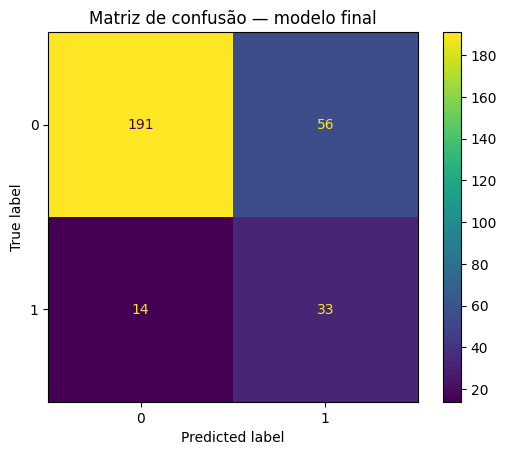

---------------------
Modelo final: SVM
              precision    recall  f1-score   support

           0       0.92      0.81      0.86       247
           1       0.38      0.62      0.47        47

    accuracy                           0.78       294
   macro avg       0.65      0.71      0.66       294
weighted avg       0.83      0.78      0.80       294



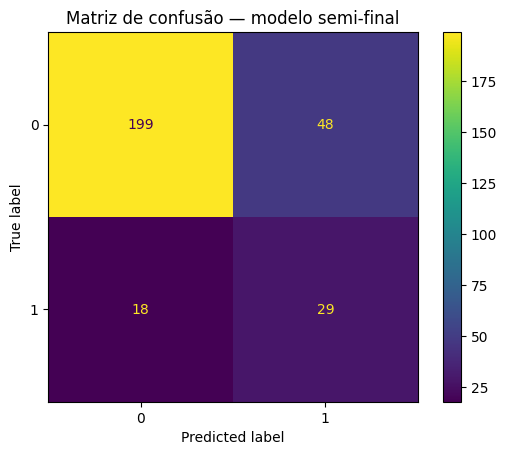

In [102]:
# === Avaliação final ===
final_model_name = "LogisticRegression"
final_model = estimators[final_model_name]

semi_final_model_name = "SVM"
semi_final_model = estimators[semi_final_model_name]

print("Modelo final:", final_model_name)

y_pred = final_model.predict(X_test)
print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_estimator(final_model, X_test, y_test)
plt.title("Matriz de confusão — modelo final")
plt.show()

print("---------------------")
print("Modelo final:", semi_final_model_name)

y_pred = semi_final_model.predict(X_test)
print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_estimator(semi_final_model, X_test, y_test)
plt.title("Matriz de confusão — modelo semi-final")
plt.show()


## 10.1 Variáveis que afetam atrittion


In [103]:
# LOGISTIC REGRESSION VARIABLES
print(final_model_name, "variáveis")
coef = estimators[final_model_name].named_steps["model"].coef_[0]
feature_names = estimators[final_model_name].named_steps["preprocess"].get_feature_names_out()
variables = pd.DataFrame({"feature": feature_names, "coef": coef}).sort_values("coef", ascending=False)
print(variables[abs(variables["coef"]) >= 0.3])


LogisticRegression variáveis
                                  feature      coef
48                      cat__OverTime_Yes  0.549590
22  cat__BusinessTravel_Travel_Frequently  0.428230
37     cat__JobRole_Laboratory Technician  0.421696
19           num__YearsSinceLastPromotion  0.345401
46              cat__MaritalStatus_Single  0.313123
3            num__EnvironmentSatisfaction -0.310376
21         cat__BusinessTravel_Non-Travel -0.323419
47                       cat__OverTime_No -0.550530


In [104]:
#SVM VARIABLES
# feature_names = estimators[semi_final_model_name].named_steps["preprocess"].get_feature_names_out()
# result = permutation_importance(
#   estimators[semi_final_model_name],
#   X_test, y_test, n_repeats=10,
#   random_state=SEED
# )

# features_df = pd.DataFrame({
#     "feature": X_test.columns,
#     "importance": result.importances_mean
# }).sort_values("importance", ascending=False)

# print(semi_final_model_name, "variáveis")
# # print(features_df)
# print(features_df[features_df["importance"] >= 0.005])


## 10.1 Análise de erros e limitações

Escreva uma análise crítica dos resultados.

**Perguntas para responder:**
- Quais tipos de erro o modelo comete mais?
- Há sinais de overfitting ou underfitting?
- A métrica escolhida captura bem o objetivo do problema?
- Há viés, limitação de dados ou risco de generalização?
- Em quais cenários o modelo não deveria ser usado?

**Resposta:**  
> _Preencha aqui._


# 11. Comparação final dos modelos

Apresente uma síntese comparativa.

| Modelo | Métrica principal | Outras métricas | Tempo de treino | Observações |
|---|---:|---:|---:|---|
| Baseline | _preencha_ | _preencha_ | _preencha_ | _preencha_ |
| Modelo 1 | _preencha_ | _preencha_ | _preencha_ | _preencha_ |
| Modelo 2 | _preencha_ | _preencha_ | _preencha_ | _preencha_ |
| Modelo otimizado | _preencha_ | _preencha_ | _preencha_ | _preencha_ |

> **Comentário:** esta tabela ajuda o leitor a entender por que o modelo final foi escolhido.


# 12. Boas práticas e rastreabilidade

Documente decisões importantes do projeto.

**O que incluir:**
- seed utilizada;
- principais decisões de pré-processamento;
- modelos testados;
- hiperparâmetros relevantes;
- tempo aproximado de treino;
- recursos computacionais usados;
- limitações conhecidas;
- o que foi tentado e descartado.

**Registro de decisões:**

| Decisão | Justificativa | Impacto esperado |
|---|---|---|
| Seed = 42 | Garantir que os resultados sejam reproduzidos | Qualquer pessoa consegue produzir os mesmos resultados |
| _ex.: usar F1-score_ | _classes desbalanceadas_ | _avaliar melhor a classe minoritária_ |
| _ex.: remover coluna X_ | _vazamento de dados_ | _evitar desempenho artificial_ |
| _ex.: usar Random Forest_ | _capturar não linearidades_ | _melhorar baseline_ |


# 13. Conclusão

Faça o fechamento do MVP conectando o resultado ao problema inicial.

**O que incluir:**
- objetivo do trabalho;
- melhor solução encontrada;
- comparação com baseline;
- principais aprendizados;
- limitações;
- próximos passos.

**Conclusão:**  
> _Preencha aqui._

> **Comentário:** uma boa conclusão não repete apenas métricas. Ela explica o que os resultados significam no contexto do problema.


# 14. Salvamento de artefatos

Esta seção é opcional, mas recomendada quando o treinamento for demorado.

**O que pode ser salvo:**
- pipeline final;
- modelo treinado;
- encoder/scaler;
- tabela de resultados;
- gráficos importantes.

> **Comentário:** se salvar arquivos, garanta que o notebook continue executando do início ao fim. Não dependa de arquivos locais que o professor não terá.


In [105]:
# Exemplo opcional de salvamento do pipeline/modelo final.
# Descomente se fizer sentido para o seu projeto.

# import joblib
# if final_model is not None:
#     joblib.dump(final_model, "modelo_final.pkl")
#     print("Modelo salvo como modelo_final.pkl")


# 15. Apêndice opcional: Deep Learning, Fine-tuning ou métodos avançados

Use esta seção apenas se o projeto realmente precisar.

**O que documentar se usar deep learning/fine-tuning:**
- arquitetura ou modelo pré-treinado;
- preparação específica dos dados;
- tamanho de batch;
- número de épocas;
- função de perda;
- otimizador;
- early stopping;
- uso de GPU/CPU;
- tempo de treino;
- comparação com baseline simples.

> **Comentário:** deep learning não é obrigatório. Um modelo clássico bem avaliado pode ser uma solução melhor para muitos MVPs.


CYNTIA:
- SMOTE??